# 03b — Spatial Features: Sentinel-2 Satellite Indices
## MietOptimal / RentSignal

Compute satellite-derived neighborhood features from Sentinel-2 imagery:
- **NDVI** — Normalized Difference Vegetation Index (green space density)
- **NDWI** — Normalized Difference Water Index (water proximity)
- **NDBI** — Normalized Difference Built-up Index (urbanization intensity)

Aggregated to PLZ-level zonal statistics, then merged with OSM features for model retraining.

**Data source:** Microsoft Planetary Computer (free, no account needed)  
**Output:** `data/processed/spatial_satellite_features.csv`

In [2]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import rasterio
from rasterio.mask import mask as rio_mask
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterstats import zonal_stats
import pystac_client
import planetary_computer
import warnings
warnings.filterwarnings("ignore")

print("All imports loaded")

All imports loaded


## 1. Load PLZ boundaries

We need PLZ polygons to compute zonal statistics from satellite rasters.

In [3]:
# Load PLZ boundaries from 03a output
plz_gdf = gpd.read_file("../data/processed/berlin_plz_boundaries.geojson")
print(f"Loaded {len(plz_gdf)} PLZ boundaries")

# For zonal stats we need polygons, but 03a saved points (from Nominatim fallback)
# Create buffer polygons (~500m radius) around centroids as approximate PLZ areas
if plz_gdf.geometry.geom_type.iloc[0] == "Point":
    print("PLZ geometries are points — creating 500m buffer polygons")
    plz_gdf = plz_gdf.to_crs(epsg=25833)
    plz_gdf["geometry"] = plz_gdf.geometry.buffer(500)
    plz_gdf = plz_gdf.to_crs(epsg=4326)

# Berlin bounding box for satellite search
berlin_bbox = plz_gdf.total_bounds  # [minx, miny, maxx, maxy]
print(f"Berlin bbox: {berlin_bbox}")
plz_gdf.head()

Loaded 190 PLZ boundaries
PLZ geometries are points — creating 500m buffer polygons
Berlin bbox: [13.132461   52.38112619 13.71009282 52.64439418]


,plz,geometry
0,10115,"POLYGON ((13.39116 52.53205, 13.39114 52.53161..."
1,10117,"POLYGON ((13.39513 52.51762, 13.39511 52.51718..."
2,10119,"POLYGON ((13.41288 52.53022, 13.41286 52.52978..."
3,10178,"POLYGON ((13.41717 52.52138, 13.41715 52.52094..."
4,10179,"POLYGON ((13.4238 52.5122, 13.42378 52.51176, ..."


## 2. Search Sentinel-2 imagery via Planetary Computer

Find a cloud-free summer scene (June-August) for Berlin. Summer gives best NDVI signal.

In [4]:
# Connect to Planetary Computer STAC catalog
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)

# Search for Sentinel-2 L2A (atmospherically corrected) over Berlin, summer 2024
search = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=berlin_bbox,
    datetime="2024-06-01/2024-08-31",
    query={"eo:cloud_cover": {"lt": 10}},  # <10% cloud cover
    sortby=[{"field": "properties.eo:cloud_cover", "direction": "asc"}],
    max_items=10,
)

items = list(search.items())
print(f"Found {len(items)} cloud-free summer 2024 scenes")
for item in items[:5]:
    cc = item.properties["eo:cloud_cover"]
    date = item.properties["datetime"][:10]
    print(f"  {date} — {cc:.1f}% cloud cover — {item.id}")

Found 10 cloud-free summer 2024 scenes
  2024-08-20 — 0.6% cloud cover — S2B_MSIL2A_20240820T100559_R022_T33UUU_20240820T143808
  2024-08-20 — 0.4% cloud cover — S2B_MSIL2A_20240820T100559_R022_T32UQD_20240820T143808
  2024-08-13 — 0.0% cloud cover — S2B_MSIL2A_20240813T101559_R065_T33UVU_20240813T133715
  2024-08-13 — 0.0% cloud cover — S2B_MSIL2A_20240813T101559_R065_T33UUU_20240813T133715
  2024-08-13 — 0.0% cloud cover — S2B_MSIL2A_20240813T101559_R065_T32UQD_20240813T133715


In [5]:
# Select best (lowest cloud cover) scene
best = items[0]
print(f"Selected: {best.id}")
print(f"Date: {best.properties['datetime'][:10]}")
print(f"Cloud cover: {best.properties['eo:cloud_cover']:.1f}%")
print(f"\nAvailable bands:")
for key in sorted(best.assets.keys()):
    if key.startswith(("B", "S")):
        print(f"  {key}: {best.assets[key].href.split('/')[-1]}")

Selected: S2B_MSIL2A_20240820T100559_R022_T33UUU_20240820T143808
Date: 2024-08-20
Cloud cover: 0.6%

Available bands:
  B01: hE7vUWhEFkS1RYEAg65daDFkmTPggM%3D
  B02: hE7vUWhEFkS1RYEAg65daDFkmTPggM%3D
  B03: hE7vUWhEFkS1RYEAg65daDFkmTPggM%3D
  B04: hE7vUWhEFkS1RYEAg65daDFkmTPggM%3D
  B05: hE7vUWhEFkS1RYEAg65daDFkmTPggM%3D
  B06: hE7vUWhEFkS1RYEAg65daDFkmTPggM%3D
  B07: hE7vUWhEFkS1RYEAg65daDFkmTPggM%3D
  B08: hE7vUWhEFkS1RYEAg65daDFkmTPggM%3D
  B09: hE7vUWhEFkS1RYEAg65daDFkmTPggM%3D
  B11: hE7vUWhEFkS1RYEAg65daDFkmTPggM%3D
  B12: hE7vUWhEFkS1RYEAg65daDFkmTPggM%3D
  B8A: hE7vUWhEFkS1RYEAg65daDFkmTPggM%3D
  SCL: hE7vUWhEFkS1RYEAg65daDFkmTPggM%3D


## 3. Read satellite bands

Read only the bands we need, cropped to Berlin bbox:
- **B03** (Green, 10m) — for NDWI
- **B04** (Red, 10m) — for NDVI
- **B08** (NIR, 10m) — for NDVI, NDWI, NDBI
- **B11** (SWIR, 20m) — for NDBI

In [7]:
from shapely.geometry import box

def read_band(item, band_name):
    """Read a full Sentinel-2 band as float32 array."""
    href = item.assets[band_name].href
    
    with rasterio.open(href) as src:
        data = src.read(1).astype(np.float32)
        profile = src.profile.copy()
        profile.update({"dtype": "float32"})
        
    print(f"  {band_name}: {data.shape} pixels, range [{data.min():.0f}, {data.max():.0f}]")
    return data, profile

print("Reading bands (streaming full tile from cloud, may take 2-3 min)...")

# Read the 4 bands we need
b03, prof_10m = read_band(best, "B03")   # Green (10m)
b04, _ = read_band(best, "B04")           # Red (10m)
b08, _ = read_band(best, "B08")           # NIR (10m)
b11, prof_20m = read_band(best, "B11")    # SWIR (20m)

print(f"\n10m bands shape: {b04.shape}")
print(f"20m band shape:  {b11.shape}")

Reading bands (streaming full tile from cloud, may take 2-3 min)...
  B03: (10980, 10980) pixels, range [0, 19936]
  B04: (10980, 10980) pixels, range [0, 18864]
  B08: (10980, 10980) pixels, range [0, 17600]
  B11: (5490, 5490) pixels, range [0, 16423]

10m bands shape: (10980, 10980)
20m band shape:  (5490, 5490)


## 4. Compute spectral indices

- **NDVI** = (NIR - Red) / (NIR + Red) → vegetation density [-1, 1]
- **NDWI** = (Green - NIR) / (Green + NIR) → water bodies [-1, 1]
- **NDBI** = (SWIR - NIR) / (SWIR + NIR) → built-up areas [-1, 1]

In [8]:
def safe_index(a, b):
    """Compute normalized difference index, handling division by zero."""
    denom = a + b
    idx = np.where(denom > 0, (a - b) / denom, 0)
    return np.clip(idx, -1, 1)

# NDVI: (NIR - Red) / (NIR + Red)
ndvi = safe_index(b08, b04)

# NDWI: (Green - NIR) / (Green + NIR)
ndwi = safe_index(b03, b08)

# NDBI needs SWIR (20m) resampled to 10m to match NIR
from scipy.ndimage import zoom
b11_10m = zoom(b11, 2, order=1)  # bilinear upsample 20m → 10m

# Crop to match 10m shape (may differ by 1 pixel due to rounding)
min_h = min(b08.shape[0], b11_10m.shape[0])
min_w = min(b08.shape[1], b11_10m.shape[1])
ndbi = safe_index(b11_10m[:min_h, :min_w], b08[:min_h, :min_w])

# Trim NDVI/NDWI to same shape
ndvi = ndvi[:min_h, :min_w]
ndwi = ndwi[:min_h, :min_w]

print(f"NDVI: shape={ndvi.shape}, range=[{ndvi.min():.3f}, {ndvi.max():.3f}], mean={ndvi.mean():.3f}")
print(f"NDWI: shape={ndwi.shape}, range=[{ndwi.min():.3f}, {ndwi.max():.3f}], mean={ndwi.mean():.3f}")
print(f"NDBI: shape={ndbi.shape}, range=[{ndbi.min():.3f}, {ndbi.max():.3f}], mean={ndbi.mean():.3f}")

NDVI: shape=(10980, 10980), range=[-1.000, 0.889], mean=0.270
NDWI: shape=(10980, 10980), range=[-1.000, 1.000], mean=-0.255
NDBI: shape=(10980, 10980), range=[-0.760, 1.000], mean=-0.086


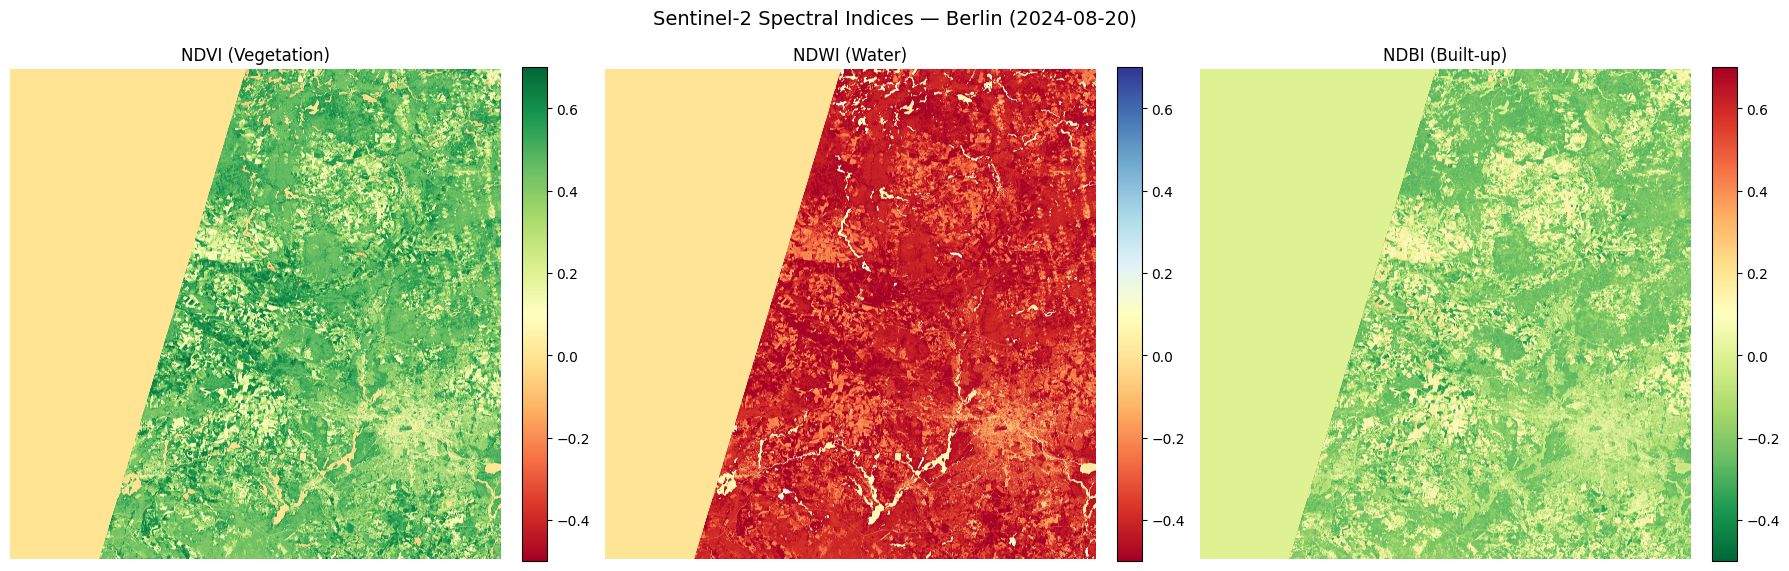

In [9]:
# Visualize the three indices
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, data, title, cmap in [
    (axes[0], ndvi, "NDVI (Vegetation)", "RdYlGn"),
    (axes[1], ndwi, "NDWI (Water)", "RdYlBu"),
    (axes[2], ndbi, "NDBI (Built-up)", "RdYlGn_r"),
]:
    im = ax.imshow(data, cmap=cmap, vmin=-0.5, vmax=0.7)
    ax.set_title(title, fontsize=12)
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle(f"Sentinel-2 Spectral Indices — Berlin ({best.properties['datetime'][:10]})", fontsize=14)
plt.tight_layout()
plt.savefig("../data/processed/satellite_indices_berlin.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Save indices as GeoTIFFs + compute zonal statistics per PLZ

In [10]:
# Save each index as a GeoTIFF for zonal stats
# Use the 10m band profile (from B03/B04/B08) as template
save_profile = prof_10m.copy()
save_profile.update({
    "height": min_h,
    "width": min_w,
    "count": 1,
    "dtype": "float32",
    "compress": "lzw",
})

indices = {"ndvi": ndvi, "ndwi": ndwi, "ndbi": ndbi}
tiff_paths = {}

for name, data in indices.items():
    path = f"../data/processed/{name}_berlin.tif"
    with rasterio.open(path, "w", **save_profile) as dst:
        dst.write(data, 1)
    tiff_paths[name] = path
    print(f"Saved: {path}")

print("\nComputing zonal statistics per PLZ...")

# Ensure PLZ polygons are in same CRS as rasters
with rasterio.open(tiff_paths["ndvi"]) as src:
    raster_crs = src.crs
plz_reproj = plz_gdf.to_crs(raster_crs)

# Compute zonal stats for each index
zonal_results = []
for name, path in tiff_paths.items():
    stats = zonal_stats(plz_reproj, path, stats=["mean", "std", "median", "min", "max"], nodata=0)
    for i, s in enumerate(stats):
        if i >= len(zonal_results):
            zonal_results.append({"plz": plz_gdf.iloc[i]["plz"]})
        zonal_results[i][f"{name}_mean"] = s["mean"]
        zonal_results[i][f"{name}_std"] = s["std"]
        zonal_results[i][f"{name}_median"] = s["median"]
    print(f"  {name}: done")

satellite_df = pd.DataFrame(zonal_results)
print(f"\nZonal statistics: {satellite_df.shape[0]} PLZs × {satellite_df.shape[1]} features")
satellite_df.describe().round(3)

Saved: ../data/processed/ndvi_berlin.tif
Saved: ../data/processed/ndwi_berlin.tif
Saved: ../data/processed/ndbi_berlin.tif

Computing zonal statistics per PLZ...
  ndvi: done
  ndwi: done
  ndbi: done

Zonal statistics: 190 PLZs × 10 features


,ndvi_mean,ndvi_std,ndvi_median,ndwi_mean,ndwi_std,ndwi_median,ndbi_mean,ndbi_std,ndbi_median
count,189.000,189.000,189.000,189.000,189.000,189.000,189.000,189.000,189.000
mean,0.296,0.137,0.290,-0.287,0.118,-0.286,-0.072,0.098,-0.070
std,0.080,0.023,0.101,0.069,0.022,0.084,0.050,0.013,0.058
min,0.088,0.052,0.060,-0.467,0.041,-0.485,-0.232,0.052,-0.245
25%,0.227,0.123,0.201,-0.332,0.106,-0.345,-0.097,0.090,-0.097
50%,0.296,0.137,0.292,-0.288,0.117,-0.291,-0.069,0.098,-0.066
75%,0.349,0.153,0.359,-0.227,0.132,-0.209,-0.034,0.107,-0.025
max,0.502,0.196,0.527,-0.101,0.187,-0.081,0.046,0.144,0.049


## 6. Visualize satellite features by PLZ

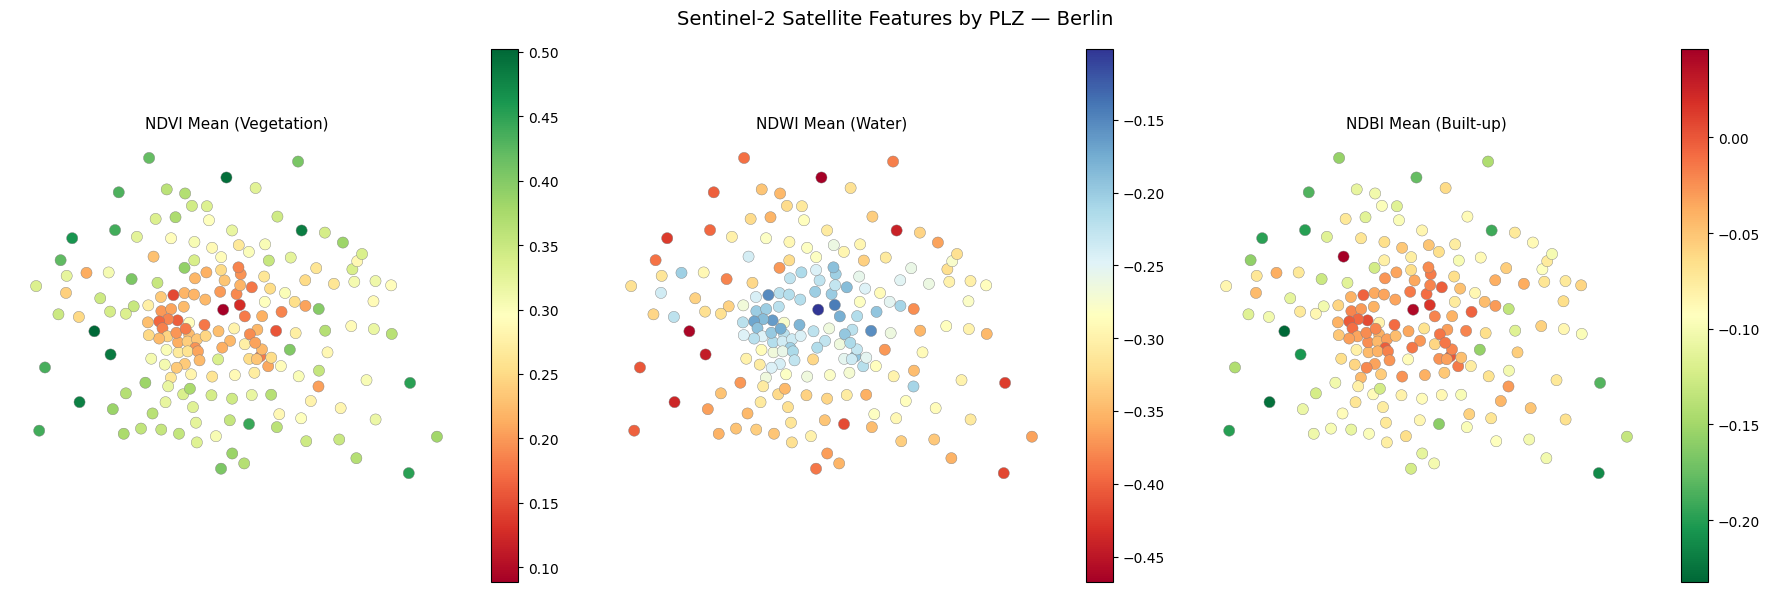

In [11]:
# Map satellite features per PLZ
plz_sat = plz_gdf.merge(satellite_df, on="plz", how="left")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, col, title, cmap in [
    (axes[0], "ndvi_mean", "NDVI Mean (Vegetation)", "RdYlGn"),
    (axes[1], "ndwi_mean", "NDWI Mean (Water)", "RdYlBu"),
    (axes[2], "ndbi_mean", "NDBI Mean (Built-up)", "RdYlGn_r"),
]:
    plz_sat.plot(column=col, cmap=cmap, legend=True, ax=ax, edgecolor="gray", linewidth=0.3)
    ax.set_title(title, fontsize=11)
    ax.axis("off")

plt.suptitle("Sentinel-2 Satellite Features by PLZ — Berlin", fontsize=14)
plt.tight_layout()
plt.show()

## 7. Correlation with rent + export

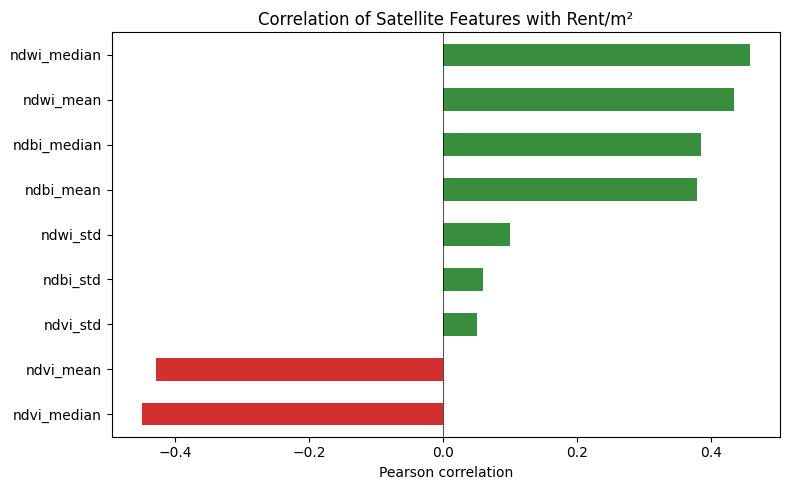


Correlation values:
ndvi_median   -0.449
ndvi_mean     -0.429
ndvi_std       0.051
ndbi_std       0.059
ndwi_std       0.099
ndbi_mean      0.378
ndbi_median    0.385
ndwi_mean      0.433
ndwi_median    0.457


In [12]:
# Merge with listings to check correlation
listings = pd.read_parquet("../data/processed/listings_clean.parquet")
listings["plz"] = listings["plz"].astype(str)
listings_sat = listings.merge(satellite_df, on="plz", how="left")

sat_cols = [c for c in satellite_df.columns if c != "plz"]
corr = listings_sat[sat_cols + ["rent_sqm"]].corr()["rent_sqm"].drop("rent_sqm").sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
corr.plot(kind="barh", ax=ax, color=["#d32f2f" if v < 0 else "#388e3c" for v in corr])
ax.set_title("Correlation of Satellite Features with Rent/m²")
ax.set_xlabel("Pearson correlation")
ax.axvline(0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

print("\nCorrelation values:")
print(corr.round(3).to_string())

In [13]:
# Save satellite features
satellite_df.to_csv("../data/processed/spatial_satellite_features.csv", index=False)
print(f"Saved: data/processed/spatial_satellite_features.csv ({satellite_df.shape[0]} rows × {satellite_df.shape[1]} cols)")

# Merge ALL spatial features (OSM + satellite) for complete spatial dataset
osm_df = pd.read_csv("../data/processed/spatial_osm_features.csv")
osm_df["plz"] = osm_df["plz"].astype(str)
satellite_df["plz"] = satellite_df["plz"].astype(str)

all_spatial = osm_df.merge(satellite_df, on="plz", how="outer")
all_spatial.to_csv("../data/processed/spatial_all_features.csv", index=False)
print(f"Saved: data/processed/spatial_all_features.csv ({all_spatial.shape[0]} rows × {all_spatial.shape[1]} cols)")

# Also update listings_with_spatial to include satellite features
listings_full = pd.read_parquet("../data/processed/listings_with_spatial.parquet")
listings_full["plz"] = listings_full["plz"].astype(str)
satellite_df_str = satellite_df.copy()
satellite_df_str["plz"] = satellite_df_str["plz"].astype(str)
listings_full = listings_full.merge(satellite_df_str, on="plz", how="left")
listings_full.to_parquet("../data/processed/listings_with_spatial.parquet", index=False)
print(f"Saved: data/processed/listings_with_spatial.parquet ({listings_full.shape[0]} rows × {listings_full.shape[1]} cols)")

print(f"\n--- All spatial features ---")
print(f"OSM: {len(osm_df.columns)-1} features")
print(f"Satellite: {len(satellite_df.columns)-1} features")
print(f"Total: {len(all_spatial.columns)-1} features per PLZ")

Saved: data/processed/spatial_satellite_features.csv (190 rows × 10 cols)
Saved: data/processed/spatial_all_features.csv (190 rows × 19 cols)
Saved: data/processed/listings_with_spatial.parquet (10275 rows × 45 cols)

--- All spatial features ---
OSM: 9 features
Satellite: 9 features
Total: 18 features per PLZ


## Next steps

- Re-run `04_spatial_model_integration.ipynb` with satellite features added → measure further R² improvement
- Expected: NDVI (green space) and NDBI (built-up intensity) should add complementary signal to OSM features
- Phase 3 (Gemini visual extraction) deferred to hackathon day